# Research Questions

## Formatting Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import ast 

In [4]:
#load all videos
all_videos = pd.read_csv('all_videos.csv')

In [5]:
#load json files
def load_json(row):
    dance_folder = row['Dance'] #folder name (same as dance)
    filename = row['alphapose_file'] #filename
    json_path = os.path.join("alphapose_json", dance_folder, filename) #get path
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as file:
            return json.load(file) #load file
    return None

In [6]:
#extract the video id from the filename
def extract_video_id(row):
    filename = row['alphapose_file']
    video_id = filename.split('-')[2].split('_')[1].split('.')[0]
    return video_id

In [7]:
#extract coordinates and normalise them 
def normalise_coordinates(row):
    alphapose = row['alphapose_coordinates']
        
    frames = {}
    for frame in alphapose:
        image_id = frame.get('image_id').split('.')[0] #get the frame number
        keypoints = frame.get('keypoints') #get keypoints
        
        if image_id not in frames: #one set of coordinates per frame (ensures only 1 person per video)
            frames[image_id] = {'keypoints': keypoints}
    
    normalised_frames = []
    for image_id, data in sorted(frames.items()):
        keypoints = data['keypoints']
        frame_coords = []
        
        for i in range(0, len(keypoints), 3):
            x, y, score = keypoints[i:i+3]
            #take those with confidence scores above 0.5 otherwise (0,0)
            if score >= 0.5:
                frame_coords.append((x, y))
            else:
                frame_coords.append((0, 0))
        
        #normalise by nose
        nose_x, nose_y = frame_coords[0]
        normalised_frame = []
        for x, y in frame_coords:
            normalised_frame.extend([x - nose_x, y - nose_y])
        normalised_frames.append(normalised_frame)
        
    return np.array(normalised_frames)

In [8]:
#calculate people in each video
def calculate_people(row):
    people = 0
    alphapose = row['alphapose_coordinates']
    for frame in alphapose:
        image_id = frame.get('image_id').split('.')[0]
        if image_id == '60': #60 frames accounts for a few seconds into the video
            people += 1 #counts how many times the frame is in the json
    return people
        
    

In [9]:
all_videos['video_id'] = all_videos.apply(extract_video_id, axis = 1)
all_videos["alphapose_coordinates"] = all_videos.apply(load_json, axis=1)
all_videos["normalised_alphapose"] = all_videos.apply(normalise_coordinates, axis=1)
all_videos["people"] = all_videos.apply(calculate_people, axis=1)
all_videos['video_metrics'] = all_videos['video_metrics'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)

In [10]:
#separate columns for likes, comments, followers, desc
all_videos['followers'] = all_videos['video_metrics'].apply(lambda x: x.get('followers', 0))
all_videos['likes'] = all_videos['video_metrics'].apply(lambda x: x.get('likes', 0))
all_videos['comments'] = all_videos['video_metrics'].apply(lambda x: x.get('comments', 0))
all_videos['desc'] = all_videos['video_metrics'].apply(lambda x: x.get('description', ''))

In [11]:
all_videos.head()

,alphapose_file,Dance,alphapose_coordinates,normalised_alphapose,dancing,people,video_id,video_metrics,followers,likes,comments,desc,dancing_encoded
0,alphapose-results-video_7401324200356531461.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 10.020523071289062, -3.34017944335...",no,4,7401324200356531461,"{'followers': 22600, 'likes': '78.2K likes', '...",22600,78.2K likes,623 comments,“ya la vieron👀”,0
1,alphapose-results-video_7423107618173947141.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 18.106781005859375, -25.3494873046...",no,2,7423107618173947141,"{'followers': 7000000, 'likes': '87.3K likes',...",7000000,87.3K likes,1073 comments,“#duet with @Brianna #POV You live in a world...,0
2,alphapose-results-video_7405720331949853957.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",no,0,7405720331949853957,"{'followers': 244700, 'likes': '470.6K likes',...",244700,470.6K likes,4786 comments,“¿Funciona Lovette feromonas?🤢😡”,0
3,alphapose-results-video_7397542554331303174.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 21.1041259765625, -14.069427490234...",yes,1,7397542554331303174,"{'followers': 44100000, 'likes': '461.9K likes...",44100000,461.9K likes,10.4K comments,“comenten emojis verdes 💚”,1
4,alphapose-results-video_7391225934390545694.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 44.438995361328125, -35.5512084960...",yes,1,7391225934390545694,"{'followers': 2600000, 'likes': '89.3K likes',...",2600000,89.3K likes,215 comments,“dance creds: @Kelley Heyer”,1


In [12]:
#converts likes into full numbers
def convert_likes(row):
    like = str(row['likes']).strip()  #ensure it's a string and remove spaces
    try:
        if 'K' in like:
            return int(float(like.replace('K', '').split()[0]) * 1000) #if k, multiply by 1000
        elif 'M' in like:
            return int(float(like.replace('M', '').split()[0]) * 1000000) #if M multiply by 1000000
        else:
            return int(float(like.split()[0]))
    except ValueError:
        return 0 

In [13]:
#converts comments into full numbers
def convert_comments(row):
    comment = str(row['comments']).strip()  #ensure it's a string and remove spaces
    try:
        if 'K' in comment:
            return int(float(comment.replace('K', '').split()[0]) * 1000) #if k, multiply by 1000
        elif 'M' in comment:
            return int(float(comment.replace('M', '').split()[0]) * 1000000)  #if M multiply by 1000000
        else:
            return int(float(comment.split()[0]))
    except ValueError:
        return 0 

In [14]:
all_videos["likes"] = all_videos.apply(convert_likes, axis=1)
all_videos['comments'] = all_videos.apply(convert_comments, axis=1)

In [15]:
#any missing values, make na then change to zero
all_videos['likes'] = pd.to_numeric(all_videos['likes'], errors='coerce')
all_videos['comments'] = pd.to_numeric(all_videos['comments'], errors='coerce')
all_videos['followers'] = pd.to_numeric(all_videos['followers'], errors='coerce')

all_videos['likes'].fillna(0, inplace=True)
all_videos['comments'].fillna(0, inplace=True)
all_videos['followers'].fillna(0, inplace=True)

/tmp/ipykernel_4000961/3161398657.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_videos['likes'].fillna(0, inplace=True)
/tmp/ipykernel_4000961/3161398657.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [16]:
#log scales for metrics
all_videos['log_likes'] = np.log1p(all_videos['likes'])
all_videos['log_comments'] = np.log1p(all_videos['comments'])
all_videos['log_followers'] = np.log1p(all_videos['followers'])

In [17]:
all_videos.head()

,alphapose_file,Dance,alphapose_coordinates,normalised_alphapose,dancing,people,video_id,video_metrics,followers,likes,comments,desc,dancing_encoded,log_likes,log_comments,log_followers
0,alphapose-results-video_7401324200356531461.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 10.020523071289062, -3.34017944335...",no,4,7401324200356531461,"{'followers': 22600, 'likes': '78.2K likes', '...",22600.0,78200,623,“ya la vieron👀”,0,11.267038,6.436150,10.025749
1,alphapose-results-video_7423107618173947141.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 18.106781005859375, -25.3494873046...",no,2,7423107618173947141,"{'followers': 7000000, 'likes': '87.3K likes',...",7000000.0,87300,1073,“#duet with @Brianna #POV You live in a world...,0,11.377117,6.979145,15.761421
2,alphapose-results-video_7405720331949853957.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",no,0,7405720331949853957,"{'followers': 244700, 'likes': '470.6K likes',...",244700.0,470600,4786,“¿Funciona Lovette feromonas?🤢😡”,0,13.061766,8.473659,12.407792
3,alphapose-results-video_7397542554331303174.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 21.1041259765625, -14.069427490234...",yes,1,7397542554331303174,"{'followers': 44100000, 'likes': '461.9K likes...",44100000.0,461900,10400,“comenten emojis verdes 💚”,1,13.043106,9.249657,17.601970
4,alphapose-results-video_7391225934390545694.json,apple,"[{'image_id': '0.jpg', 'category_id': 1, 'keyp...","[[0.0, 0.0, 44.438995361328125, -35.5512084960...",yes,1,7391225934390545694,"{'followers': 2600000, 'likes': '89.3K likes',...",2600000.0,89300,215,“dance creds: @Kelley Heyer”,1,11.399768,5.375278,14.771022


## Question 1

**Average Likes**

In [18]:
#average likes of videos by soundtrack and their count
avg_likes = all_videos.groupby(['Dance', 'dancing']).agg(
    avg_likes=('likes', 'mean'),
    video_count=('video_id', 'count')
).reset_index()

In [19]:
all_videos_filtered = all_videos[all_videos['likes'] != 0]

In [20]:
avg_likes

,Dance,dancing,avg_likes,video_count
0,apple,no,307099.835505,614
1,apple,yes,303527.699482,386
2,cannibal,no,235955.465331,649
3,cannibal,yes,332880.056980,351
4,savage,no,513324.994565,736
5,savage,yes,768438.253788,264
6,sayso,no,341122.320182,659
7,sayso,yes,405844.941349,341
8,supalonely,no,481521.323843,843
9,supalonely,yes,546079.605096,157


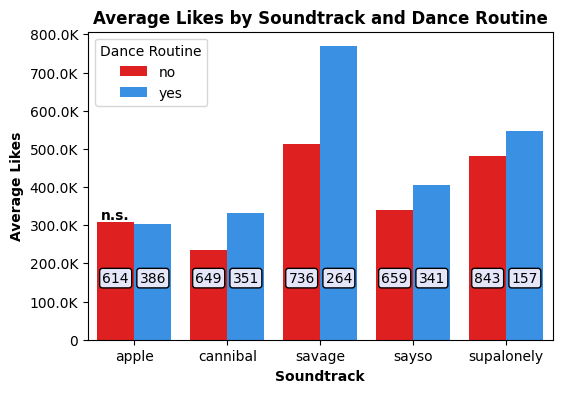

In [21]:
#plot average likes
import seaborn as sns  
from matplotlib.ticker import FuncFormatter

#sns.set_context("poster", font_scale=0.8)

colours = ['red', 'dodgerblue']

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=avg_likes, x='Dance', y='avg_likes', hue='dancing', palette = colours, hue_order = ['no', 'yes'])

#allows to add video counts onto bars
avg_y_position = ax.get_ylim()[1] * 0.2

for i in range(len(avg_likes)):
    bar = ax.patches[i]
    
    bar_height = bar.get_height()
    bar_x = bar.get_x() + bar.get_width() / 2  #x position at the center of the bar
    
    video_count = avg_likes.loc[avg_likes['avg_likes'] == bar_height, 'video_count'].iloc[0] 

    #place text
    ax.text(bar_x, avg_y_position, f'{video_count}', ha='center', va='center', fontsize=10, 
            bbox=dict(facecolor='lavender', edgecolor='black', boxstyle='round, pad=0.2', linewidth=1))
    
#'n.s' on apple bar
apple_index = avg_likes[avg_likes['Dance'] == 'apple'].index[0]
apple_bar = ax.patches[apple_index] 


ax.text(apple_bar.get_x() + apple_bar.get_width() / 2, apple_bar.get_height() + 0.05,
        "n.s.", ha='center', va='bottom', fontsize=10, color="black", fontweight='bold')

#plot graph
plt.xlabel('Soundtrack', fontweight = 'bold')
plt.ylabel('Average Likes', fontweight = 'bold')
plt.title('Average Likes by Soundtrack and Dance Routine', fontweight = 'bold')
plt.legend(title='Dance Routine', loc = 'upper left')

#format likes on y axis
def format_likes(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(FuncFormatter(format_likes))
#plt.savefig('average_likes_3.png', format = 'png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
#one way anova of likes for dancing and non dancing videos
from scipy.stats import f_oneway
for soundtrack, subset in all_videos.groupby('Dance'):
    not_dancing = subset[subset["dancing_encoded"] == 0]["likes"]
    dancing = subset[subset["dancing_encoded"] == 1]["likes"]
    stat = f_oneway(not_dancing, dancing)
    print(soundtrack)
    print(stat)

apple
F_onewayResult(statistic=0.013944897124136147, pvalue=0.9060212866197163)
cannibal
F_onewayResult(statistic=4.995679874136073, pvalue=0.025631267967745692)
savage
F_onewayResult(statistic=11.73702966899284, pvalue=0.0006376537586067565)
sayso
F_onewayResult(statistic=2.331128930622003, pvalue=0.12712672503189934)
supalonely
F_onewayResult(statistic=1.1744820340676059, pvalue=0.27874395880956254)


In [23]:
#subset of videos
subset_150 = (
    all_videos
    .groupby(['Dance', 'dancing'], group_keys=False)
    .apply(lambda x: x.sample(n=150, random_state=42) if len(x) >= 150 else x)
)

/tmp/ipykernel_4000961/4002949835.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=150, random_state=42) if len(x) >= 150 else x)


In [24]:
#repeat above steps for subset

In [25]:
avg_likes_subset = subset_150.groupby(['Dance', 'dancing']).agg(
    avg_likes=('likes', 'mean'),
    video_count=('video_id', 'count')
).reset_index()

In [26]:
avg_likes_subset

,Dance,dancing,avg_likes,video_count
0,apple,no,288000.000000,150
1,apple,yes,285106.660000,150
2,cannibal,no,242088.660000,150
3,cannibal,yes,299089.333333,150
4,savage,no,537984.000000,150
5,savage,yes,830892.666667,150
6,sayso,no,361842.073333,150
7,sayso,yes,479595.500000,150
8,supalonely,no,472557.333333,150
9,supalonely,yes,558123.986667,150


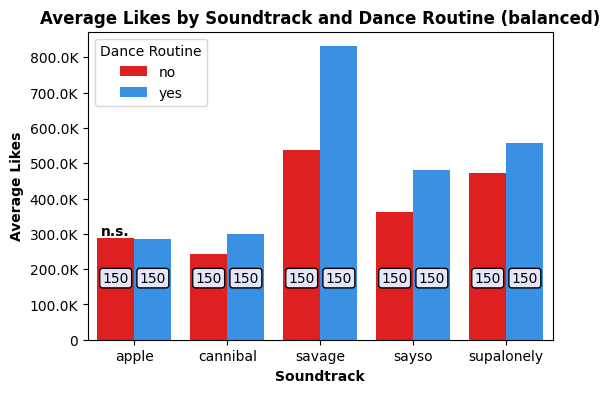

In [27]:
import seaborn as sns  
from matplotlib.ticker import FuncFormatter

#sns.set_context("poster", font_scale=0.8)

colours = ['red', 'dodgerblue']

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=avg_likes_subset, x='Dance', y='avg_likes', hue='dancing', palette = colours, hue_order = ['no', 'yes'])

avg_y_position = ax.get_ylim()[1] * 0.2

for i in range(len(avg_likes_subset)):
    bar = ax.patches[i]
    
    bar_height = bar.get_height()
    bar_x = bar.get_x() + bar.get_width() / 2
    
    video_count = avg_likes_subset.loc[avg_likes_subset['avg_likes'] == bar_height, 'video_count'].iloc[0]

    ax.text(bar_x, avg_y_position, f'{video_count}', ha='center', va='center', fontsize=10, 
            bbox=dict(facecolor='lavender', edgecolor='black', boxstyle='round, pad=0.2', linewidth=1))
    
apple_index = avg_likes_subset[avg_likes_subset['Dance'] == 'apple'].index[0]
apple_bar = ax.patches[apple_index] 


ax.text(apple_bar.get_x() + apple_bar.get_width() / 2, apple_bar.get_height() + 0.05,
        "n.s.", ha='center', va='bottom', fontsize=10, color="black", fontweight='bold')

plt.xlabel('Soundtrack', fontweight = 'bold')
plt.ylabel('Average Likes', fontweight = 'bold')
plt.title('Average Likes by Soundtrack and Dance Routine (balanced)', fontweight = 'bold')
plt.legend(title='Dance Routine', loc = 'upper left')


def format_likes(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(FuncFormatter(format_likes))
#plt.savefig('average_likes_balanced.png', format = 'png', dpi=300, bbox_inches='tight')
plt.show()


**Median Likes**

In [28]:
#median of videos by soundtrack
median_likes = all_videos.groupby(['Dance', 'dancing']).agg(
    median_likes=('likes', 'median'),
    video_count=('video_id', 'count')
).reset_index()

In [29]:
median_likes

,Dance,dancing,median_likes,video_count
0,apple,no,166600.0,614
1,apple,yes,167650.0,386
2,cannibal,no,115200.0,649
3,cannibal,yes,112500.0,351
4,savage,no,315250.0,736
5,savage,yes,314850.0,264
6,sayso,no,185100.0,659
7,sayso,yes,191700.0,341
8,supalonely,no,292700.0,843
9,supalonely,yes,303200.0,157


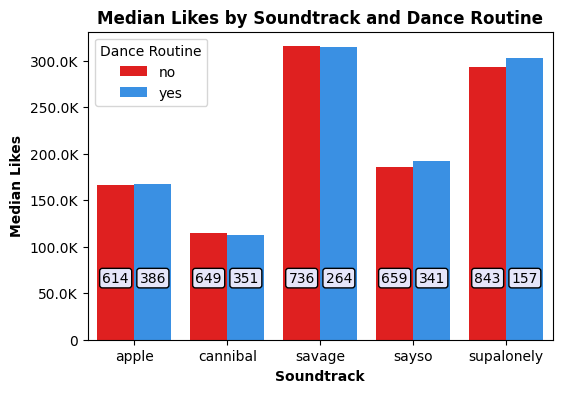

In [31]:
#plot median likes
import seaborn as sns  
from matplotlib.ticker import FuncFormatter

#sns.set_context("poster", font_scale=0.8)

colours = ['red', 'dodgerblue']

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=median_likes, x='Dance', y='median_likes', hue='dancing', palette = colours, hue_order = ['no', 'yes'])

#plot video counts on bars
avg_y_position = ax.get_ylim()[1] * 0.2

for i in range(len(median_likes)):
    bar = ax.patches[i]
    
    bar_height = bar.get_height()
    bar_x = bar.get_x() + bar.get_width() / 2
    
    video_count = median_likes.loc[median_likes['median_likes'] == bar_height, 'video_count'].iloc[0]

    ax.text(bar_x, avg_y_position, f'{video_count}', ha='center', va='center', fontsize=10, 
            bbox=dict(facecolor='lavender', edgecolor='black', boxstyle='round, pad=0.2', linewidth=1))

#plot graph
plt.xlabel('Soundtrack', fontweight = 'bold')
plt.ylabel('Median Likes', fontweight = 'bold')
plt.title('Median Likes by Soundtrack and Dance Routine', fontweight = 'bold')
plt.legend(title='Dance Routine', loc = 'upper left')

#format likes on y axis
def format_likes(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(FuncFormatter(format_likes))
#plt.savefig('median_likes.png', format = 'png', dpi=300, bbox_inches='tight')
plt.show()


In [32]:
#same as above for subset

In [33]:
median_likes_subset = subset_150.groupby(['Dance', 'dancing']).agg(
    median_likes=('likes', 'median'),
    video_count=('video_id', 'count')
).reset_index()

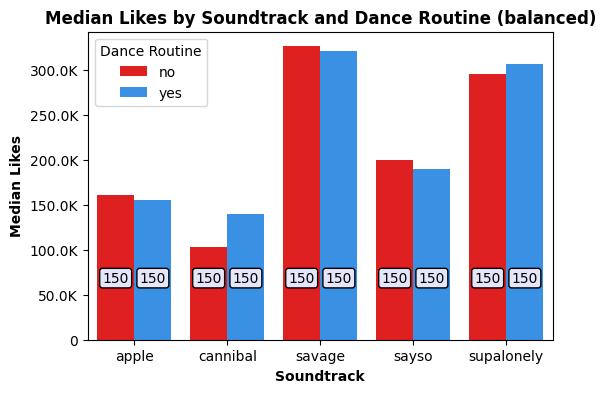

In [34]:
import seaborn as sns  
from matplotlib.ticker import FuncFormatter

#sns.set_context("poster", font_scale=0.8)

colours = ['red', 'dodgerblue']

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=median_likes_subset, x='Dance', y='median_likes', hue='dancing', palette = colours, hue_order = ['no', 'yes'])

avg_y_position = ax.get_ylim()[1] * 0.2

for i in range(len(median_likes_subset)):
    bar = ax.patches[i]
    
    bar_height = bar.get_height()
    bar_x = bar.get_x() + bar.get_width() / 2
    
    video_count = median_likes_subset.loc[median_likes_subset['median_likes'] == bar_height, 'video_count'].iloc[0]

    ax.text(bar_x, avg_y_position, f'{video_count}', ha='center', va='center', fontsize=10, 
            bbox=dict(facecolor='lavender', edgecolor='black', boxstyle='round, pad=0.2', linewidth=1))

plt.xlabel('Soundtrack', fontweight = 'bold')
plt.ylabel('Median Likes', fontweight = 'bold')
plt.title('Median Likes by Soundtrack and Dance Routine (balanced)', fontweight = 'bold')
plt.legend(title='Dance Routine', loc = 'upper left')


def format_likes(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(FuncFormatter(format_likes))
#plt.savefig('median_likes_balanced.png', format = 'png', dpi=300, bbox_inches='tight')
plt.show()


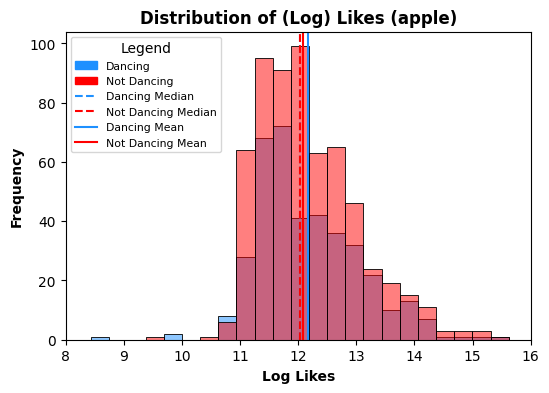

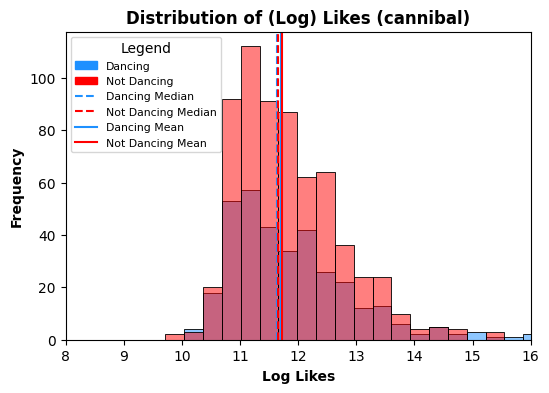

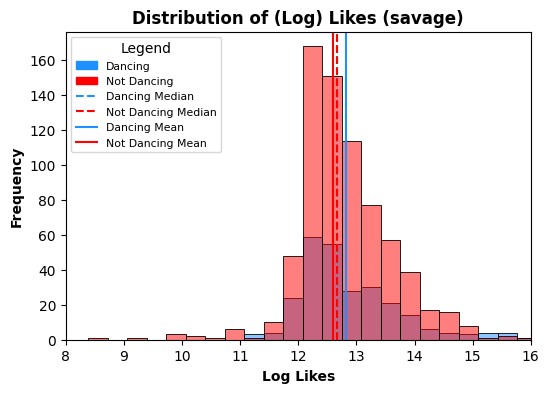

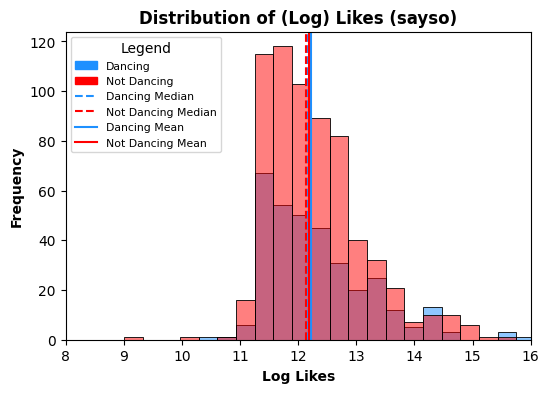

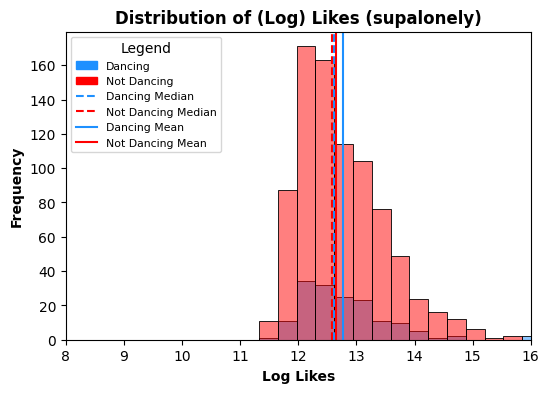

In [35]:
#distribution of log likes - not used
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

for soundtrack, subset in all_videos.groupby('Dance'):
    colours = ['red', 'dodgerblue']
    plt.figure(figsize=(6, 4))
    
    sns.histplot(data=subset, x='log_likes', bins=50, hue='dancing', palette=colours, hue_order = ['no', 'yes'])
    
    #add lines to graph
    median_dance = subset[subset['dancing'] == 'yes']['log_likes'].median()
    median_no_dance = subset[subset['dancing'] == 'no']['log_likes'].median()

    mean_dance = subset[subset['dancing'] == 'yes']['log_likes'].mean()
    mean_no_dance = subset[subset['dancing'] == 'no']['log_likes'].mean()

    plt.axvline(median_dance, color='dodgerblue', linestyle='--')
    plt.axvline(median_no_dance, color='red', linestyle='--')
    plt.axvline(mean_dance, color='dodgerblue', linestyle='-')
    plt.axvline(mean_no_dance, color='red', linestyle='-')
    
    #legend
    histogram_patches = [
        Patch(color='dodgerblue', label='Dancing'),
        Patch(color='red', label='Not Dancing')
    ]
    line_patches = [
        Line2D([0], [0], color='dodgerblue', linestyle='--', label='Dancing Median'),
        Line2D([0], [0], color='red', linestyle='--', label='Not Dancing Median'),
        Line2D([0], [0], color='dodgerblue', linestyle='-', label='Dancing Mean'),
        Line2D([0], [0], color='red', linestyle='-', label='Not Dancing Mean')
    ]

    plt.legend(handles=histogram_patches + line_patches, title='Legend', loc='upper left', fontsize = 7.8)

    plt.title(f'Distribution of (Log) Likes ({soundtrack})', fontweight = 'bold')
    plt.xlabel('Log Likes', fontweight = 'bold')
    plt.ylabel('Frequency', fontweight = 'bold')
    plt.xlim([8, 16])
    #plt.savefig(f'likes_distribution_{soundtrack}.png', format = 'png', dpi=300, bbox_inches='tight')
    plt.show()


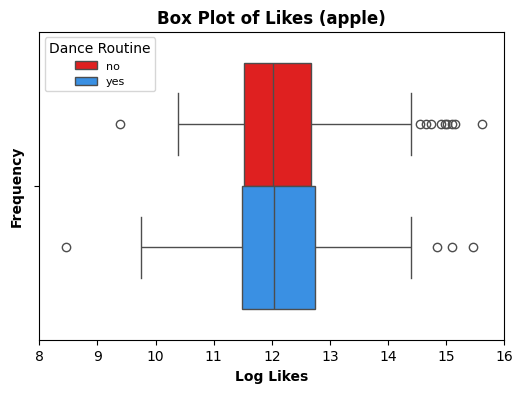

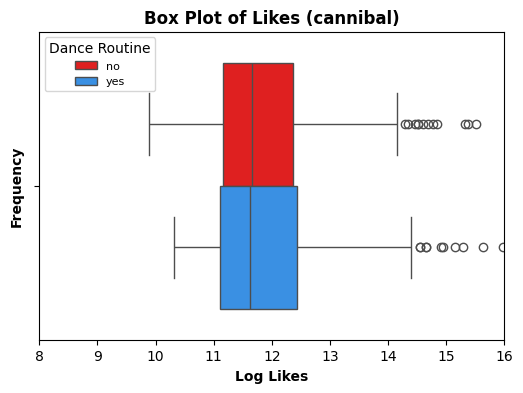

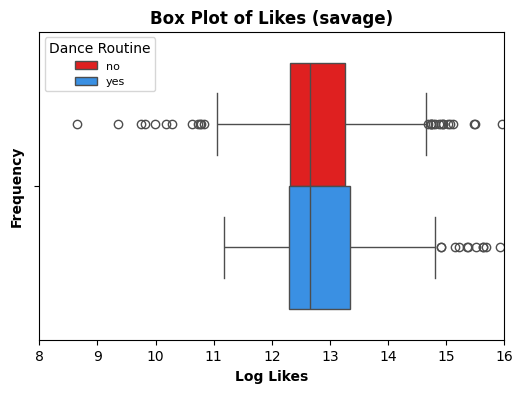

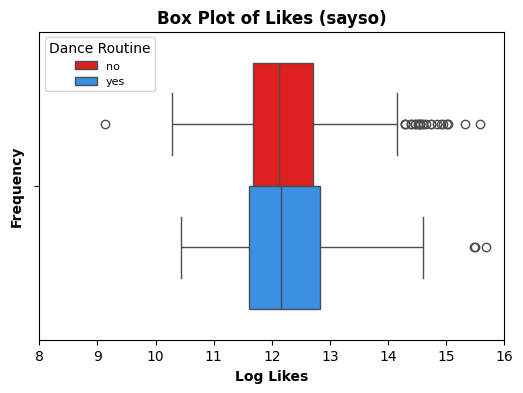

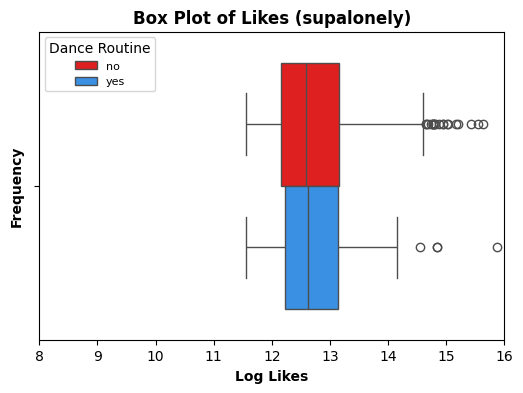

In [36]:
#box plots
for soundtrack, subset in all_videos.groupby('Dance'):
    colours = ['red', 'dodgerblue']
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=subset, x='log_likes', hue = 'dancing', palette = colours, hue_order = ['no', 'yes'])
    plt.legend(title='Dance Routine', loc = 'upper left', fontsize = 8)
    plt.title(f'Box Plot of Likes ({soundtrack})', fontweight = 'bold')
    plt.xlabel('Log Likes', fontweight = 'bold')
    plt.ylabel('Frequency', fontweight = 'bold')
    plt.xlim([8,16]) #limit axis for better display
  
    #plt.savefig(f'likes_boxplot_{soundtrack}.png', format = 'png', dpi=300, bbox_inches='tight')
    plt.show()

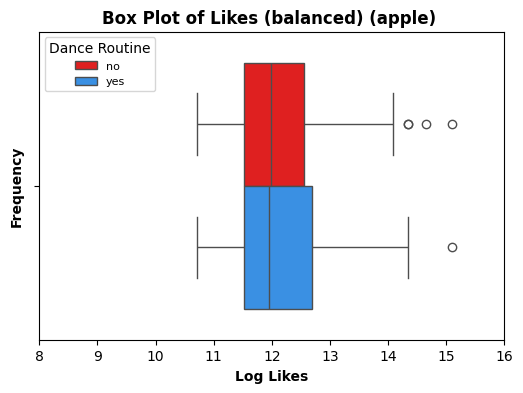

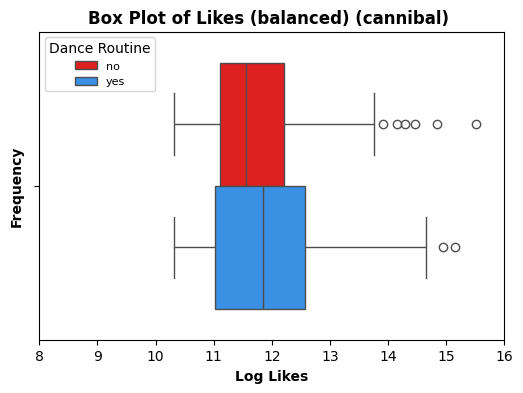

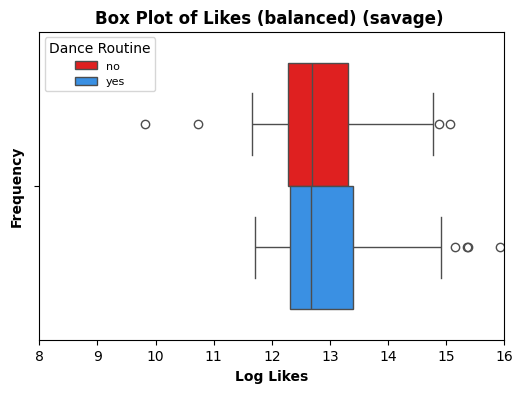

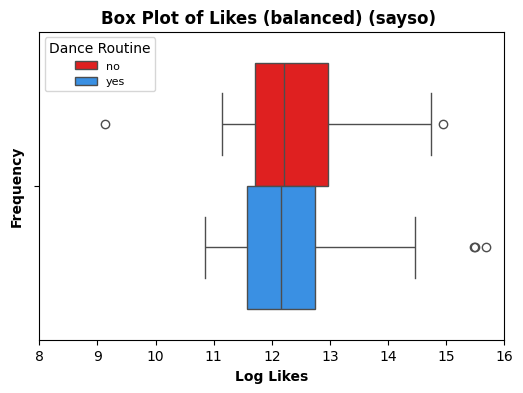

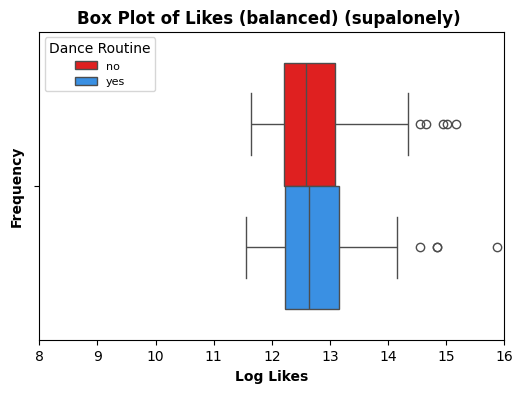

In [37]:
#same as above for balanced data
for soundtrack, subset in subset_150.groupby('Dance'):
    colours = ['red', 'dodgerblue']
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=subset, x='log_likes', hue = 'dancing', palette = colours, hue_order = ['no', 'yes'])
    plt.legend(title='Dance Routine', loc = 'upper left', fontsize = 8)
    plt.title(f'Box Plot of Likes (balanced) ({soundtrack}) ', fontweight = 'bold')
    plt.xlabel('Log Likes', fontweight = 'bold')
    plt.ylabel('Frequency', fontweight = 'bold')
    plt.xlim([8,16])
    #plt.savefig(f'likes_boxplot_{soundtrack}_balanced.png', format = 'png', dpi=300, bbox_inches='tight')
    plt.show()

In [38]:
#min likes for each group
min_likes = all_videos.groupby(['Dance', 'dancing']).agg(
    min_likes=('likes', 'min'),
    video_count=('video_id', 'count')
).reset_index()

In [39]:
min_likes

,Dance,dancing,min_likes,video_count
0,apple,no,0,614
1,apple,yes,4695,386
2,cannibal,no,0,649
3,cannibal,yes,0,351
4,savage,no,0,736
5,savage,yes,0,264
6,sayso,no,0,659
7,sayso,yes,0,341
8,supalonely,no,0,843
9,supalonely,yes,104500,157


In [40]:
#max likes for each group
max_likes = all_videos.groupby(['Dance', 'dancing']).agg(
    max_likes=('likes', 'max'),
    video_count=('video_id', 'count')
).reset_index()

In [41]:
max_likes

,Dance,dancing,max_likes,video_count
0,apple,no,6100000,614
1,apple,yes,5200000,386
2,cannibal,no,5500000,649
3,cannibal,yes,10800000,351
4,savage,no,8500000,736
5,savage,yes,19300000,264
6,sayso,no,5900000,659
7,sayso,yes,9600000,341
8,supalonely,no,6200000,843
9,supalonely,yes,10600000,157


**Question 1a)**

apple
intercept: 12.119984443516918
coefficient: [0.01102889]
mse: 1.4672702847952603
r2: 4.712512415805392e-05


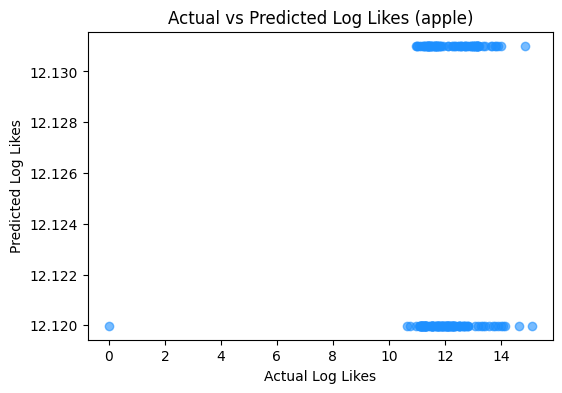

cannibal
intercept: 11.721750011613578
coefficient: [-0.00473697]
mse: 3.0730692485754583
r2: -0.00035993827388658417


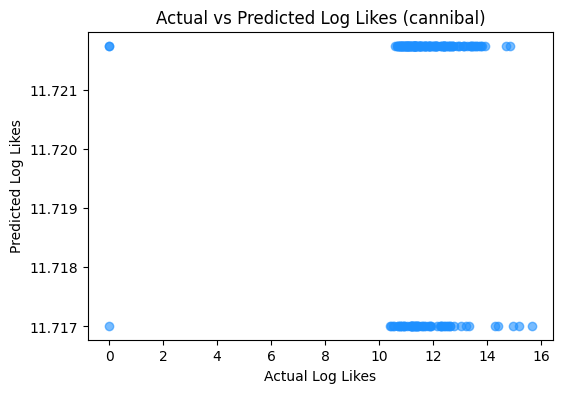

savage
intercept: 12.590115970154217
coefficient: [0.21250993]
mse: 2.178294132360443
r2: 0.0045981886876226286


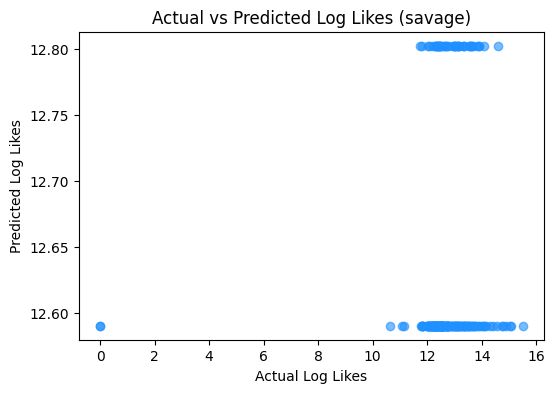

sayso
intercept: 12.171030633375553
coefficient: [0.03612006]
mse: 0.6749689240227856
r2: -0.015142589276883944


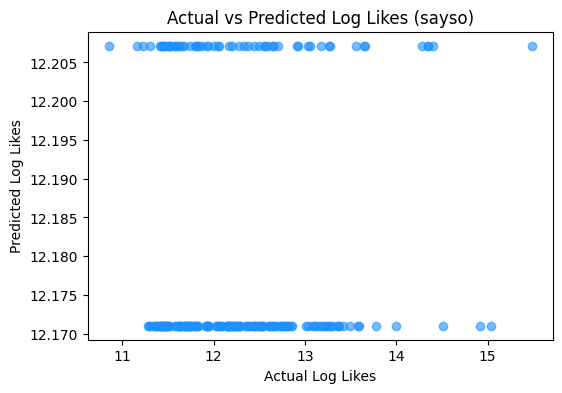

supalonely
intercept: 12.659622381357897
coefficient: [0.11712976]
mse: 1.3297923377783123
r2: -0.0008851220021375283


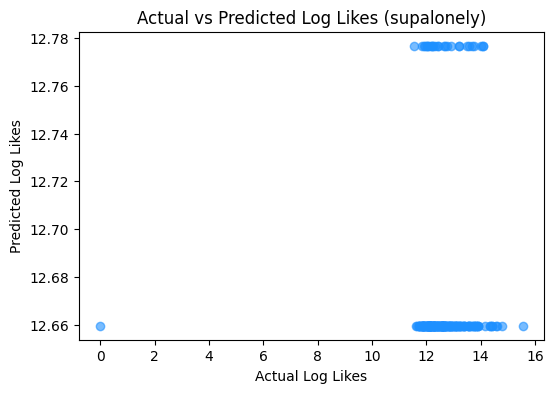

In [43]:
#regression on dancing and likes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

for soundtrack, subset in all_videos.groupby('Dance'):
    X = subset[["dancing_encoded"]]
    y = subset["log_likes"]

    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    plt.figure(figsize=(6, 4))
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, c='dodgerblue')
    
    #plt.axline((0, 0), slope=1, c = 'red')

    plt.xlabel("Actual Log Likes")
    plt.ylabel("Predicted Log Likes")
    plt.title(f"Actual vs Predicted Log Likes ({soundtrack})")
    plt.show()

apple
intercept: 7.701234007268648
coefficient: [0.18072883 0.68058942]
mse: 0.5660926294689641
r2: 0.32343791008289


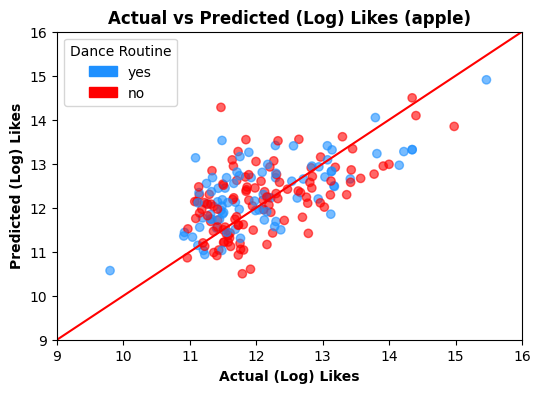

cannibal
intercept: 6.859575692251429
coefficient: [0.02731239 0.77634604]
mse: 1.2472426738862534
r2: 0.43098167286298716


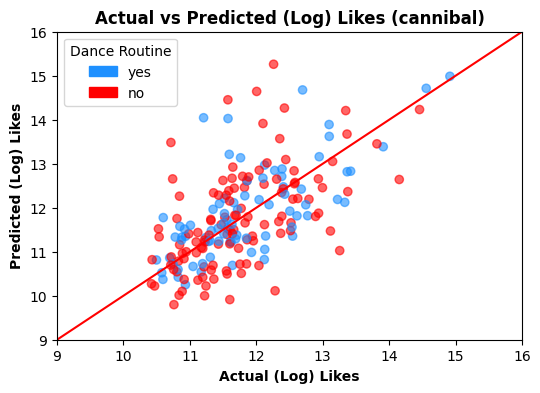

savage
intercept: 6.131560899554098
coefficient: [-0.26709643  0.92127591]
mse: 1.0751412641614462
r2: 0.5261271124377442


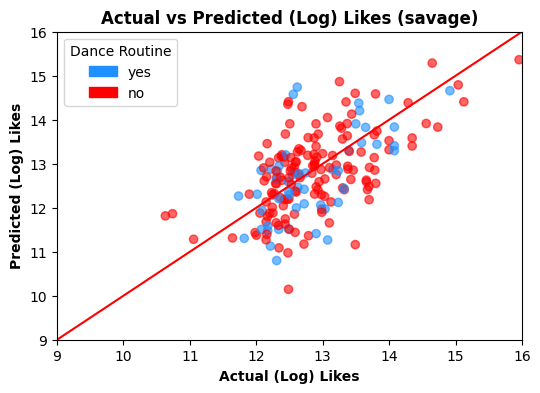

sayso
intercept: 7.83243345198467
coefficient: [2.90212926e-04 6.50549411e-01]
mse: 1.703782089882975
r2: 0.5177282493026338


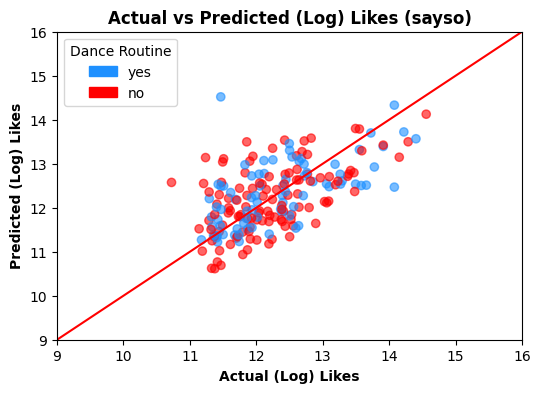

supalonely
intercept: 8.082485668084114
coefficient: [-0.05536161  0.65001486]
mse: 1.2324713858544774
r2: 0.42856033126682735


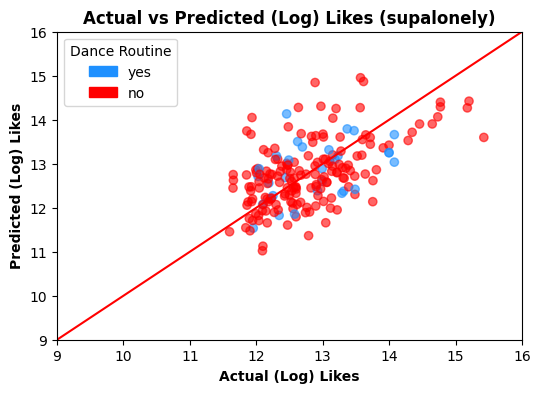

In [22]:
#regression on dancing and comments
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

for soundtrack, subset in all_videos.groupby('Dance'):
    X = subset[["dancing_encoded", "log_comments"]]
    y = subset["log_likes"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    c = [ 'red' if i==0 else 'dodgerblue' for i in X_test["dancing_encoded"].values ]
    plt.figure(figsize=(6, 4))
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, c=c)
    #sns.set_context('poster', font_scale = 0.8)
    plt.axline((0, 0), slope=1, c = 'red')
    
    plt.xlim([9, 16])
    plt.ylim([9, 16])
   
    plt.xlabel("Actual (Log) Likes", fontweight = 'bold')
    plt.ylabel("Predicted (Log) Likes", fontweight = 'bold')
    plt.title(f"Actual vs Predicted (Log) Likes ({soundtrack})", fontweight = 'bold')
    
    dance_patch = mpatches.Patch(color='dodgerblue', label='yes')
    no_dance_patch = mpatches.Patch(color='red', label='no')
    plt.legend(handles=[dance_patch, no_dance_patch], title="Dance Routine")
    #plt.savefig(f'd_c_{soundtrack}-report.png', format = 'png', dpi=300, bbox_inches='tight')
    plt.show()

apple
intercept: 8.059436450382481
coefficient: [0.09361423 0.59132687 0.02004712]
mse: 1.0455599126163295
r2: 0.5237050041782259


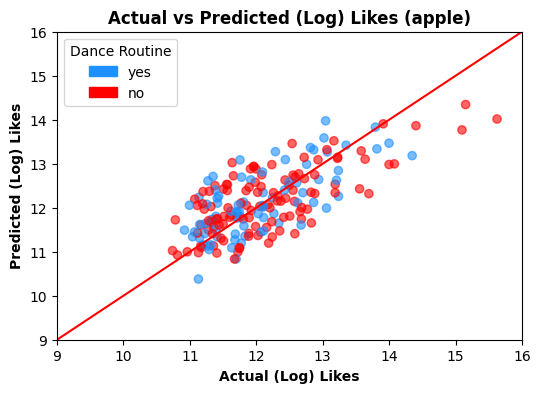

cannibal
intercept: 5.678846582628268
coefficient: [-0.148507    0.75529581  0.10174355]
mse: 1.0422676128159785
r2: 0.31176960186440394


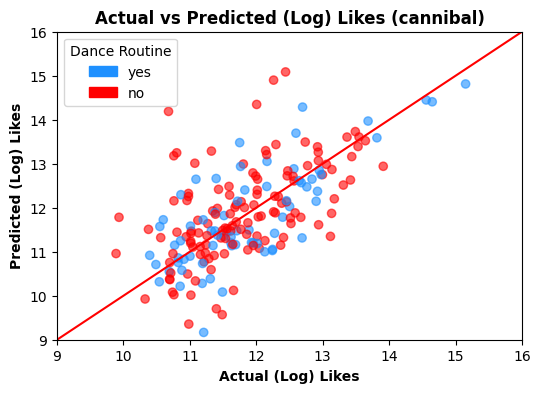

savage
intercept: 5.036317938897874
coefficient: [-0.44473881  0.87574882  0.10356638]
mse: 0.9255792630508027
r2: 0.586565343412258


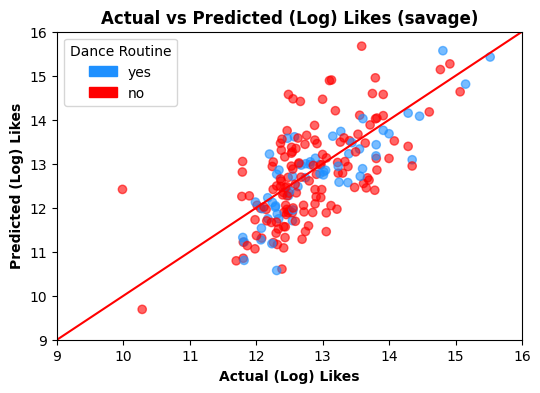

sayso
intercept: 6.580450126388494
coefficient: [-0.17887549  0.60284397  0.11527641]
mse: 1.7651309592545557
r2: 0.5561127636868123


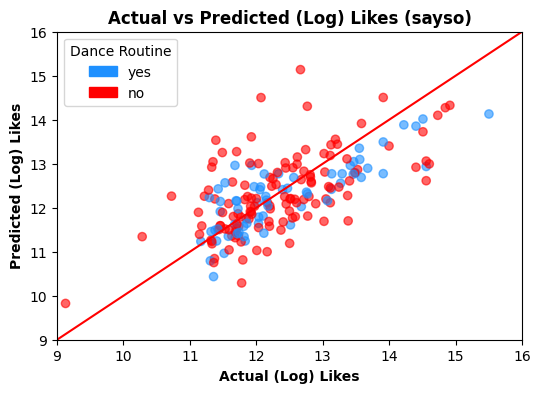

supalonely
intercept: 7.182890996593441
coefficient: [-0.11017388  0.65756625  0.05978462]
mse: 0.6601770600289525
r2: 0.5171514323953381


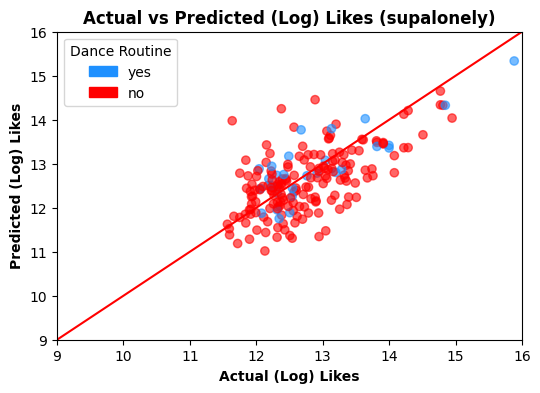

In [23]:
#regression on dancing, comments and followers
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["dancing_encoded", "log_comments", "log_followers"]]
    y = subset["log_likes"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    plt.figure(figsize=(6, 4))
    c = [ 'red' if i==0 else 'dodgerblue' for i in X_test["dancing_encoded"].values ]
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, color=c)
    
    plt.axline((0, 0), slope=1, c = 'red')

    plt.xlabel("Actual (Log) Likes", fontweight = 'bold')
    plt.ylabel("Predicted (Log) Likes", fontweight = 'bold')
    plt.title(f"Actual vs Predicted (Log) Likes ({soundtrack})", fontweight = 'bold')
    dance_patch = mpatches.Patch(color='dodgerblue', label='yes')
    no_dance_patch = mpatches.Patch(color='red', label='no')
    plt.legend(handles=[dance_patch, no_dance_patch], title="Dance Routine", loc = 'upper left')
    plt.xlim([9,16])
    plt.ylim([9,16])
    #plt.savefig(f'd_c_f{soundtrack}-report.png', format = 'png', dpi=300, bbox_inches='tight')
    plt.show()

apple
intercept: 7.748458672009319
coefficient: [0.67890198]
mse: 0.5100861717582437
r2: 0.3237316583364065


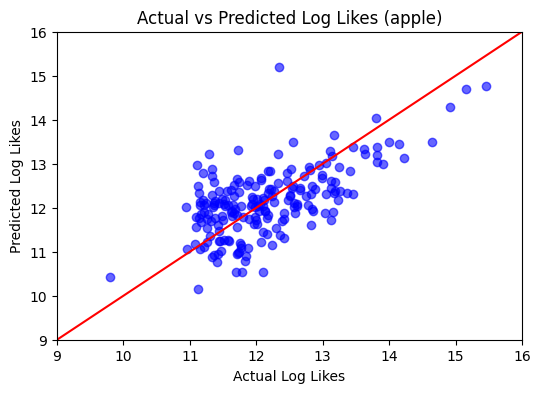

cannibal
intercept: 7.431545976382965
coefficient: [0.68519113]
mse: 1.651334280477721
r2: 0.5443428710374008


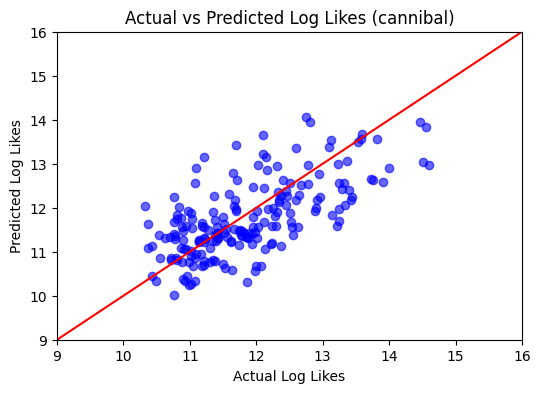

savage
intercept: 6.313203439646807
coefficient: [0.885728]
mse: 1.2599999847622316
r2: 0.6181473092298315


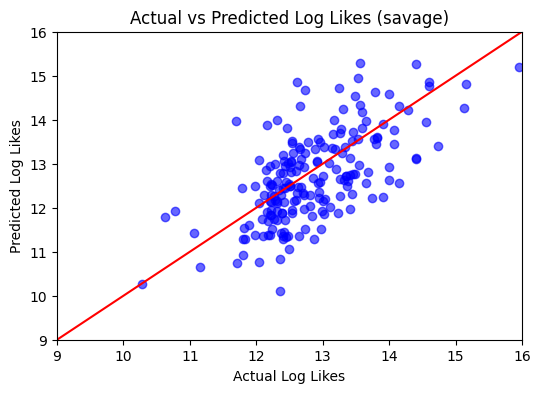

sayso
intercept: 7.3339311132862965
coefficient: [0.71785166]
mse: 0.7651311338767246
r2: 0.5443124521307872


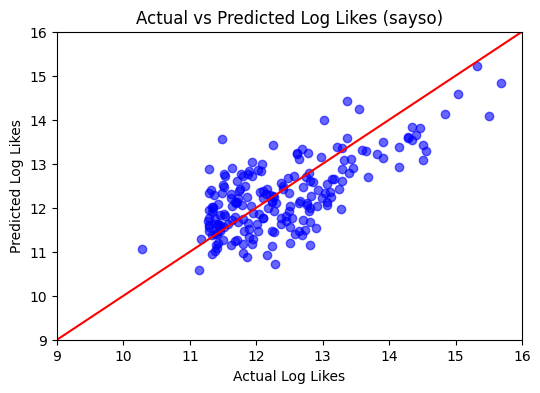

supalonely
intercept: 8.03100557208993
coefficient: [0.65090152]
mse: 0.7183492305093441
r2: 0.48873125294646014


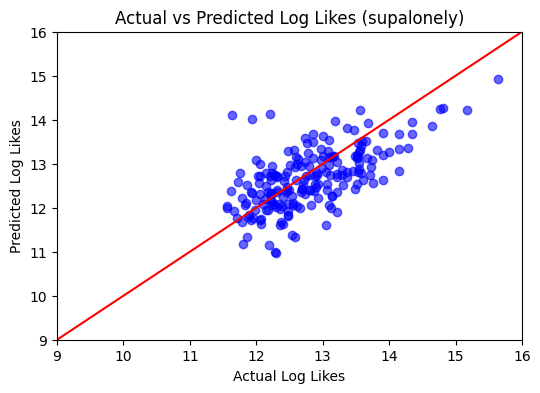

In [24]:
#regression on comments
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["log_comments"]]
    y = subset["log_likes"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    plt.figure(figsize=(6, 4))
    #c = [ 'red' if i==0 else 'dodgerblue' for i in X_test["dancing_encoded"].values ]
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, color='blue')
    
    plt.axline((0, 0), slope=1, c = 'red')

    plt.xlabel("Actual Log Likes")
    plt.ylabel("Predicted Log Likes")
    plt.title(f"Actual vs Predicted Log Likes ({soundtrack})")
    
    plt.xlim([9,16])
    plt.ylim([9,16])
    plt.show()

apple
intercept: 7.587126626432407
coefficient: [0.63274022 0.03807545]
mse: 0.7674684526648767
r2: 0.4821266328294629


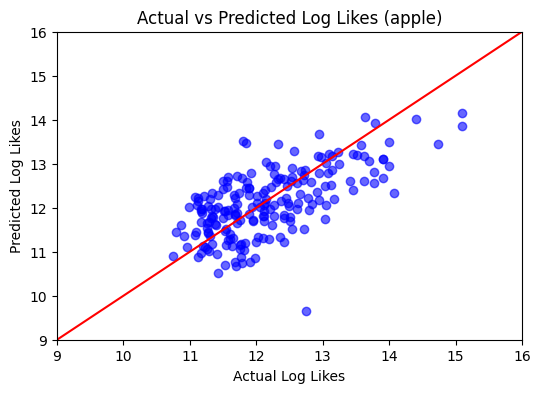

cannibal
intercept: 5.725574279857499
coefficient: [0.7547622 0.0932559]
mse: 1.0341189672981195
r2: 0.36709288486321257


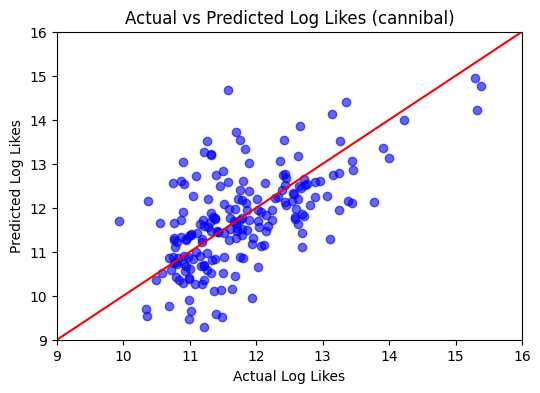

savage
intercept: 5.304868014401521
coefficient: [0.88194582 0.0735157 ]
mse: 1.0470120965082286
r2: 0.5629593583278201


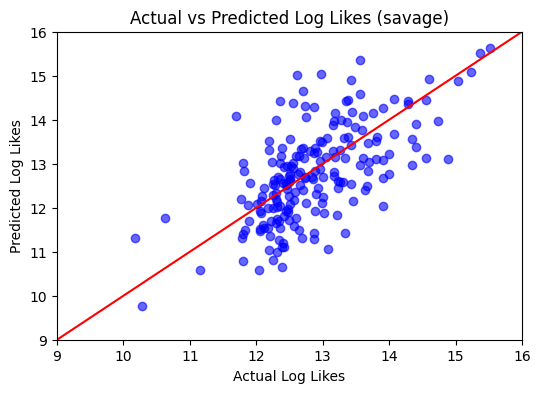

sayso
intercept: 5.783079499769687
coefficient: [0.69082127 0.12493443]
mse: 0.7517675562197033
r2: 0.47834440315785365


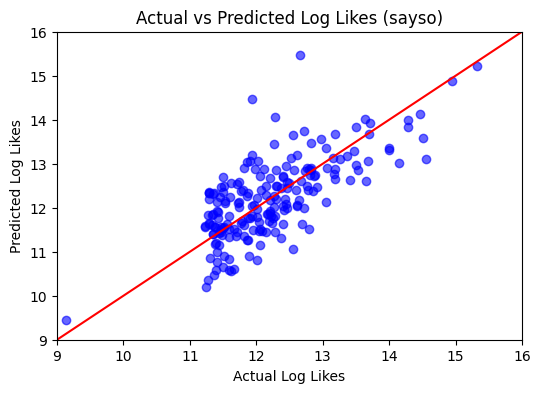

supalonely
intercept: 6.8413628778235545
coefficient: [0.65763664 0.08533889]
mse: 0.7484727725498934
r2: 0.4337447153774042


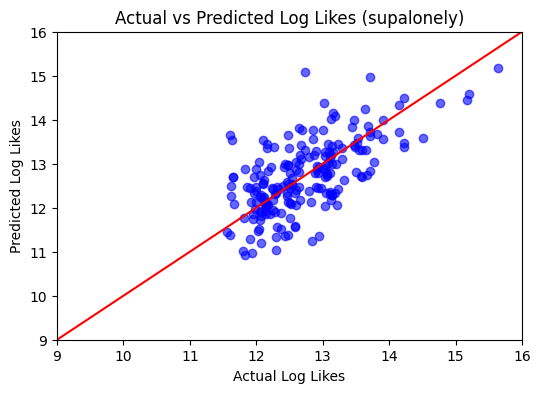

In [25]:
#regression on comments and followers
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["log_comments", "log_followers"]]
    y = subset["log_likes"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    plt.figure(figsize=(6, 4))
    #c = [ 'red' if i==0 else 'dodgerblue' for i in X_test["dancing_encoded"].values ]
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, color='blue')
    
    plt.axline((0, 0), slope=1, c = 'red')

    plt.xlabel("Actual Log Likes")
    plt.ylabel("Predicted Log Likes")
    plt.title(f"Actual vs Predicted Log Likes ({soundtrack})")
    
    plt.xlim([9,16])
    plt.ylim([9,16])
    plt.show()

apple
intercept: 11.18233232273045
coefficient: [ 0.0777999  -0.04758837]
mse: 0.7386549843641983
r2: -0.04749436396844109


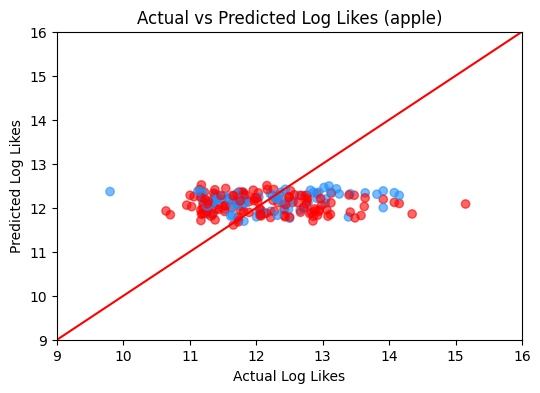

cannibal
intercept: 9.537111811715018
coefficient: [ 0.16571458 -0.16333748]
mse: 2.1067523342780374
r2: 0.09837281973315148


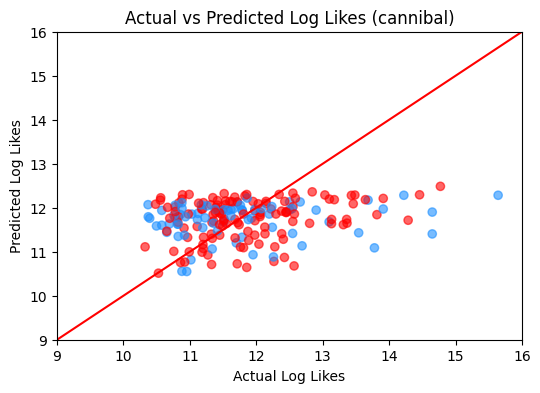

savage
intercept: 9.52320846068471
coefficient: [ 0.22542778 -0.21710889]
mse: 1.6026943740706558
r2: 0.053547054591779775


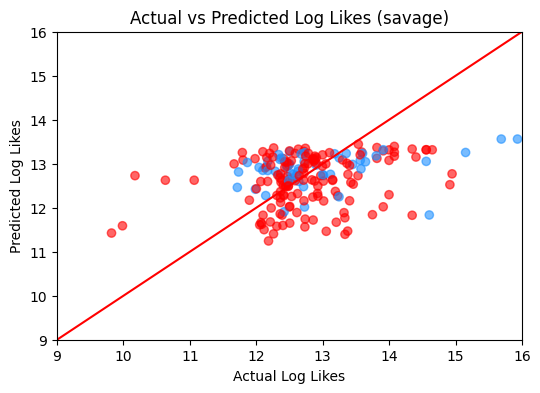

sayso
intercept: 9.9156465120537
coefficient: [ 0.16840431 -0.19549669]
mse: 2.592541811931145
r2: 0.14741866445925667


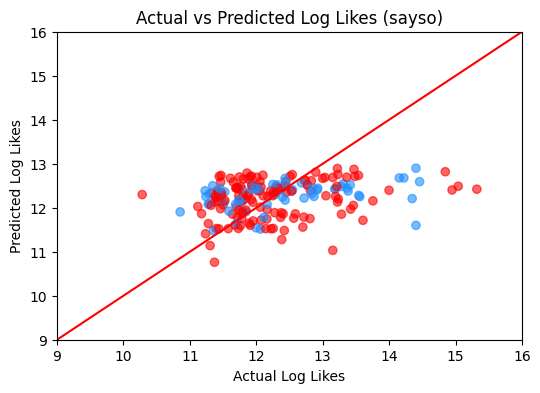

supalonely
intercept: 11.73111194765171
coefficient: [ 0.06708363 -0.00595134]
mse: 2.1451973996731515
r2: 0.061358834335255796


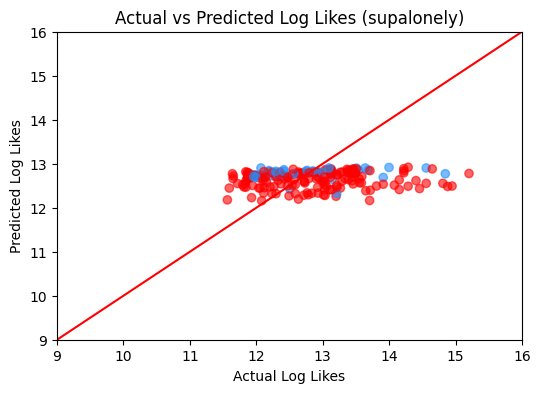

In [26]:
#regression on followers and dancing
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["log_followers", "dancing_encoded"]]
    y = subset["log_likes"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    plt.figure(figsize=(6, 4))
    c = [ 'red' if i==0 else 'dodgerblue' for i in X_test["dancing_encoded"].values ]
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, color=c)
    
    plt.axline((0, 0), slope=1, c = 'red')

    plt.xlabel("Actual Log Likes")
    plt.ylabel("Predicted Log Likes")
    plt.title(f"Actual vs Predicted Log Likes ({soundtrack})")
    
    plt.xlim([9,16])
    plt.ylim([9,16])
    plt.show()

apple
intercept: 11.467822523294831
coefficient: [0.05425516]
mse: 1.3173835257753277
r2: 0.05524850319054264


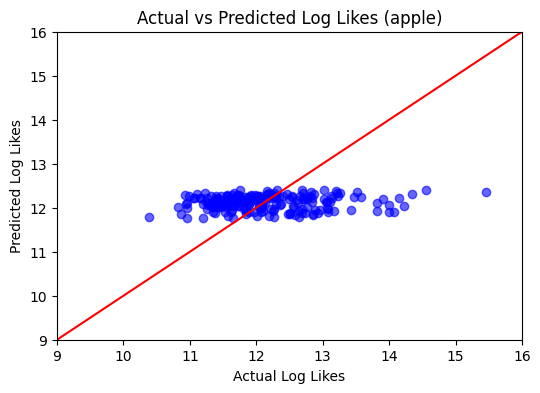

cannibal
intercept: 9.252923669128107
coefficient: [0.18070005]
mse: 0.9531736310777411
r2: -0.05223764647894513


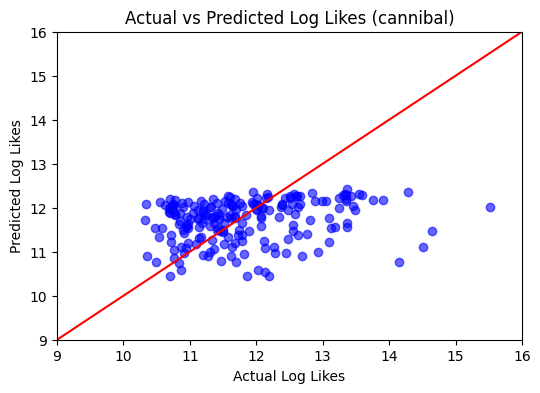

savage
intercept: 10.161184232705027
coefficient: [0.17617616]
mse: 3.438135418699053
r2: 0.14686240719582078


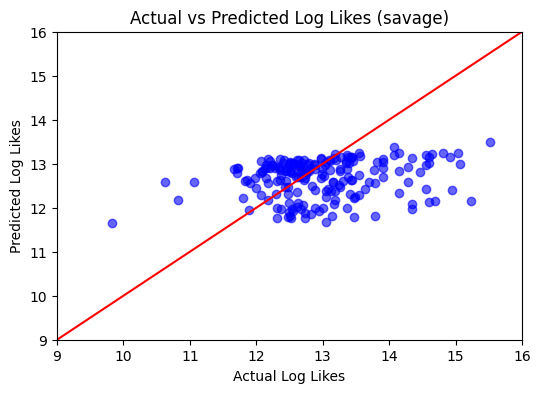

sayso
intercept: 9.261395250838554
coefficient: [0.20748468]
mse: 0.8297391346908479
r2: -0.038833069377826046


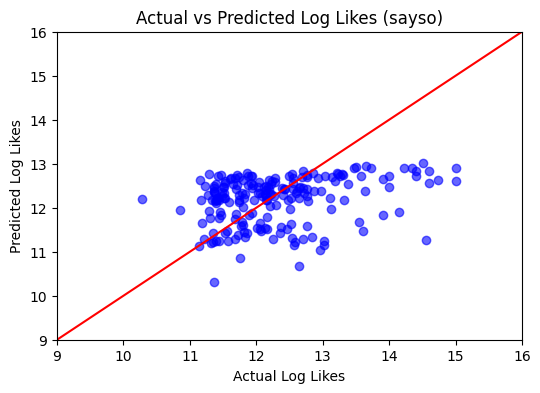

supalonely
intercept: 11.44144937349224
coefficient: [0.0889642]
mse: 1.2565307729994215
r2: 0.039965555646054196


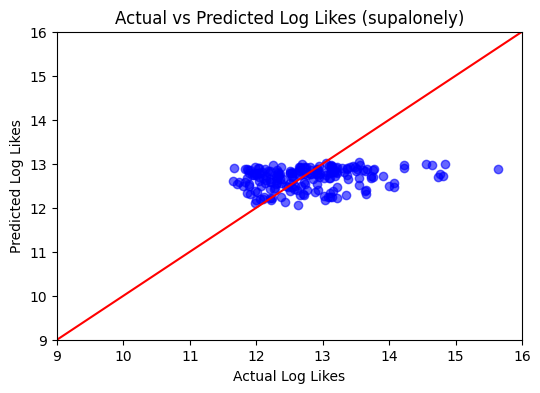

In [27]:
#regression on followers
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["log_followers"]]
    y = subset["log_likes"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    print(soundtrack)
    print(f'intercept: {model.intercept_}')
    print(f'coefficient: {model.coef_}')
    print(f'mse: {mean_squared_error(y_test, y_pred)}')
    print(f'r2: {r2_score(y_test, y_pred)}')
    
    plt.figure(figsize=(6, 4))
    #c = [ 'red' if i==0 else 'dodgerblue' for i in X_test["dancing_encoded"].values ]
    plt.scatter(x=y_test, y=y_pred, alpha = 0.6, color='blue')
    
    plt.axline((0, 0), slope=1, c = 'red')

    plt.xlabel("Actual Log Likes")
    plt.ylabel("Predicted Log Likes")
    plt.title(f"Actual vs Predicted Log Likes ({soundtrack})")
    
    plt.xlim([9,16])
    plt.ylim([9,16])
    plt.show()

**Alternative methods not used**

In [28]:
#try bins of followers
bins = [0, 1000, 10000, 100000, 500000, 1000000, 10000000, float('inf')]
labels = ['<1k', '1-10k', '10-100k', '100-500k', '500k-1M', '1-10M', '10M+']

all_videos['follower_category'] = pd.cut(all_videos['followers'], bins=bins, labels=labels)

In [29]:
all_videos['follower_category'].value_counts()

follower_category
1-10M       1854
10M+         845
10-100k      779
100-500k     695
500k-1M      384
1-10k        362
<1k           67
Name: count, dtype: int64

In [30]:
#average likes for groups
avg_likes_followers = all_videos.groupby(['Dance', 'dancing_encoded'])['likes'].mean().reset_index()
print(avg_likes_followers)


        Dance  dancing_encoded          likes
0       apple                0  307099.835505
1       apple                1  303527.699482
2    cannibal                0  235955.465331
3    cannibal                1  332880.056980
4      savage                0  513324.994565
5      savage                1  768438.253788
6       sayso                0  341122.320182
7       sayso                1  405844.941349
8  supalonely                0  481521.323843
9  supalonely                1  546079.605096


In [31]:
#average likes by bin
engagement_by_followers = all_videos.groupby(['Dance', 'dancing_encoded', 'follower_category'])['likes'].mean().reset_index()
print(engagement_by_followers)


         Dance  dancing_encoded follower_category          likes
0        apple                0               <1k  197503.125000
1        apple                0             1-10k  313492.592593
2        apple                0           10-100k  360487.647059
3        apple                0          100-500k  307520.182692
4        apple                0           500k-1M  302694.117647
..         ...              ...               ...            ...
65  supalonely                1           10-100k  401959.900000
66  supalonely                1          100-500k  469671.428571
67  supalonely                1           500k-1M  309785.714286
68  supalonely                1             1-10M  365147.524590
69  supalonely                1              10M+  789165.151515

[70 rows x 4 columns]


/tmp/ipykernel_3964837/1180714280.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  engagement_by_followers = all_videos.groupby(['Dance', 'dancing_encoded', 'follower_category'])['likes'].mean().reset_index()


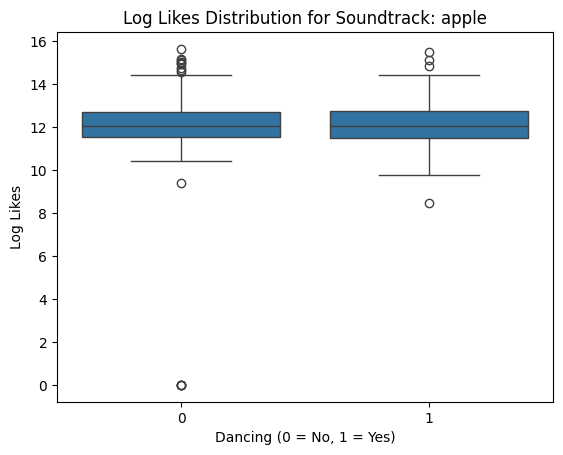

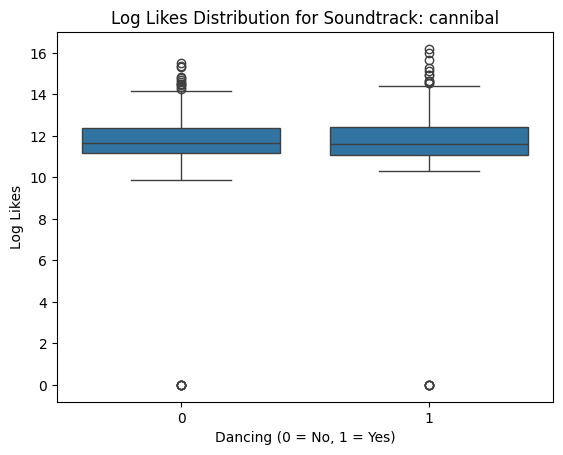

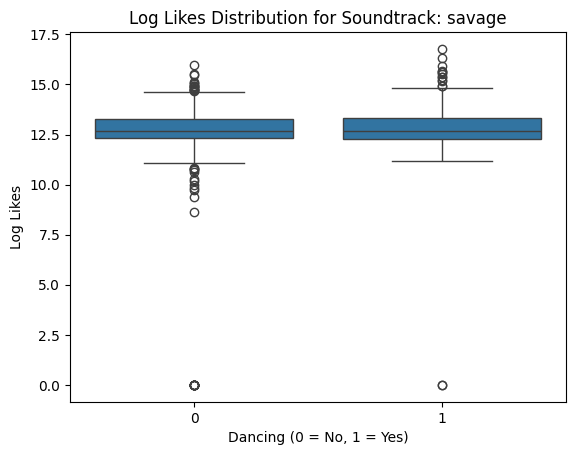

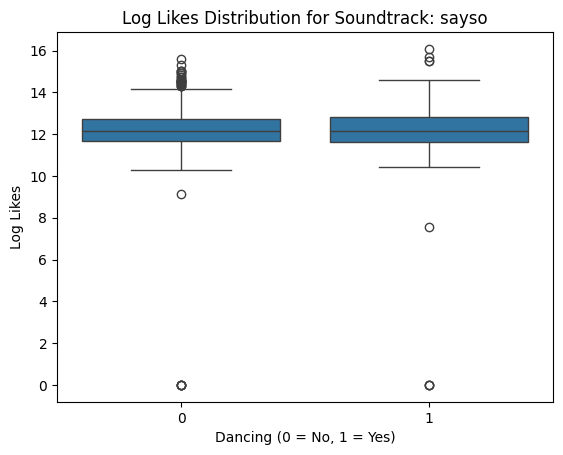

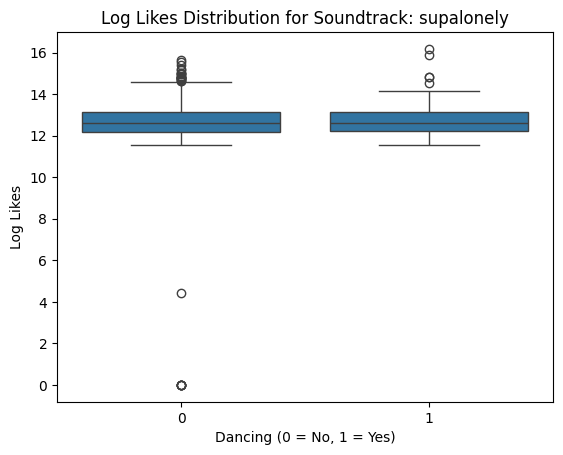

In [32]:
#tried some box plots
import seaborn as sns
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset["dancing_encoded"]
    y = subset["log_likes"]
    
    sns.boxplot(x="dancing_encoded", y="log_likes", data=subset)
    
    plt.xlabel("Dancing (0 = No, 1 = Yes)")
    plt.ylabel("Log Likes")
    plt.title(f"Log Likes Distribution for Soundtrack: {soundtrack}")
    plt.show()

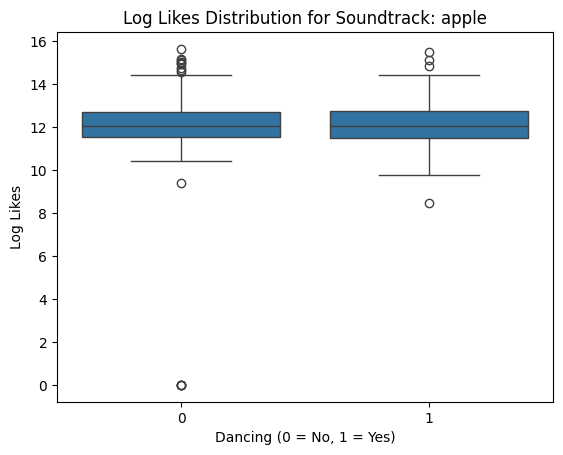

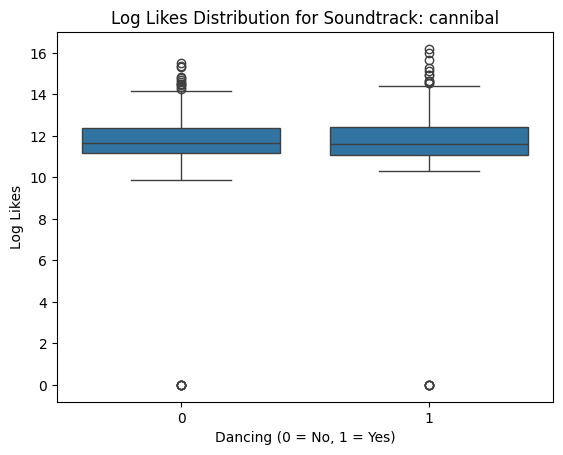

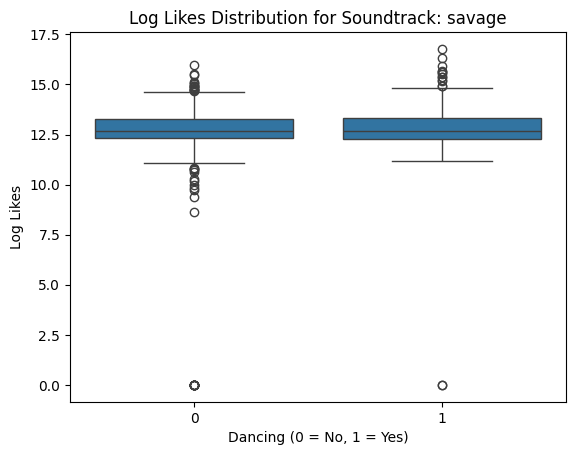

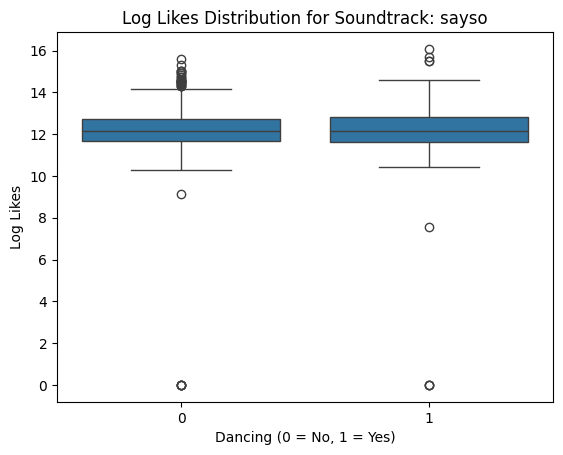

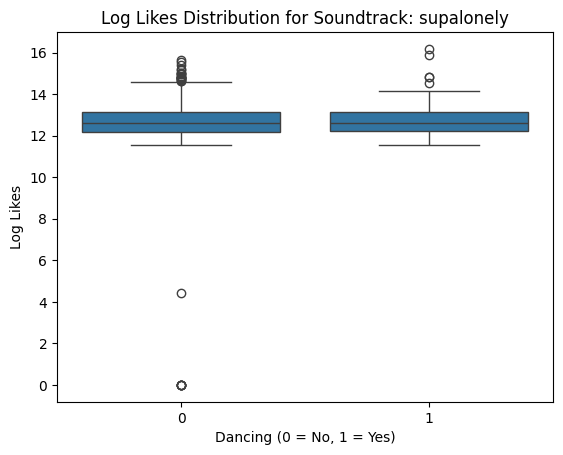

In [33]:
import seaborn as sns
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["dancing_encoded", "log_comments"]]
    y = subset["log_likes"]
    
    sns.boxplot(x="dancing_encoded", y="log_likes", data=subset)
    
    plt.xlabel("Dancing (0 = No, 1 = Yes)")
    plt.ylabel("Log Likes")
    plt.title(f"Log Likes Distribution for Soundtrack: {soundtrack}")
    plt.show()

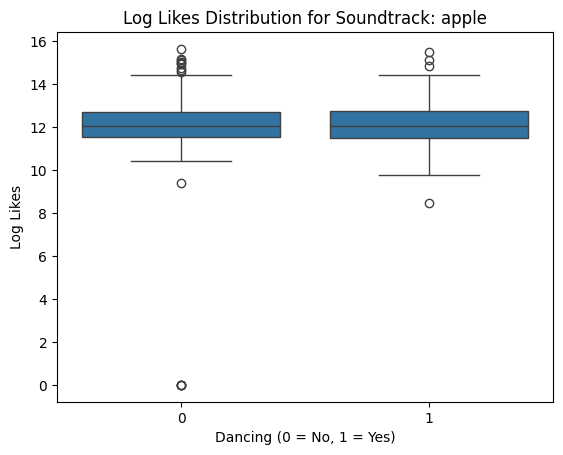

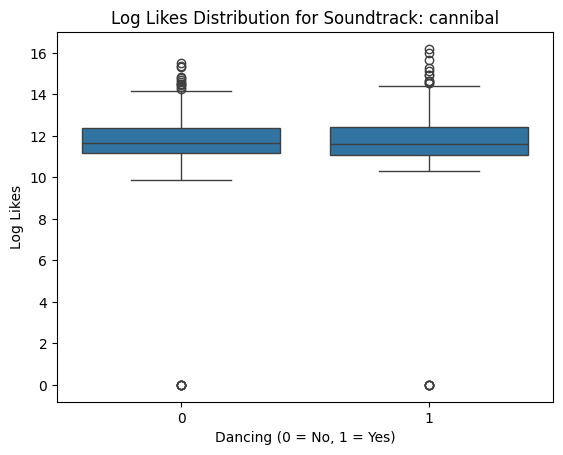

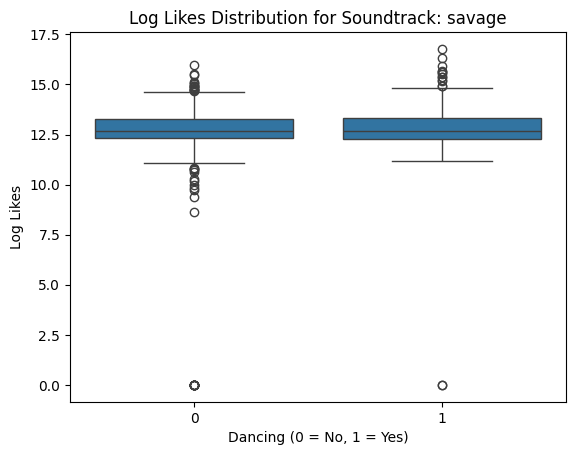

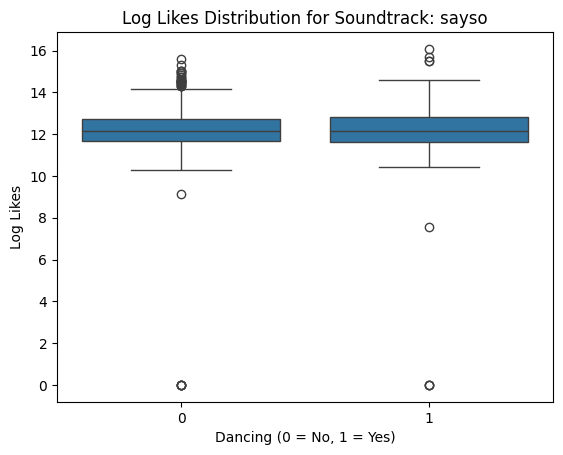

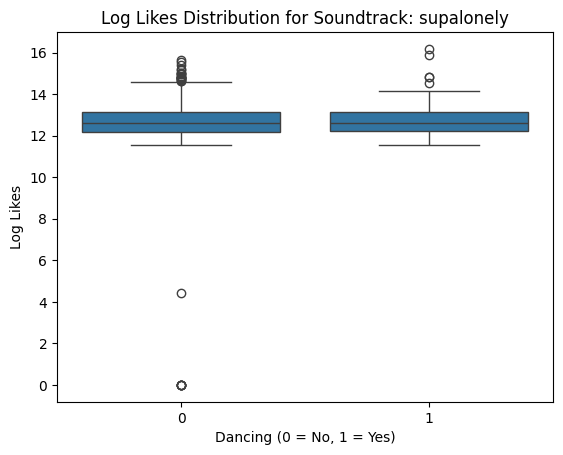

In [34]:
import seaborn as sns
for soundtrack, subset in all_videos.groupby('Dance'):

    X = subset[["dancing_encoded", "log_comments", "log_followers"]]
    y = subset["log_likes"]
    
    sns.boxplot(x="dancing_encoded", y="log_likes", data=subset)
    
    plt.xlabel("Dancing (0 = No, 1 = Yes)")
    plt.ylabel("Log Likes")
    plt.title(f"Log Likes Distribution for Soundtrack: {soundtrack}")
    plt.show()

**Question 2**

In [42]:
#categorise videos by number of people
all_videos['multiple_people'] = all_videos['people'].apply(lambda x: 'No dancers' if x == 0 else ('Multiple' if x > 1 else 'one'))

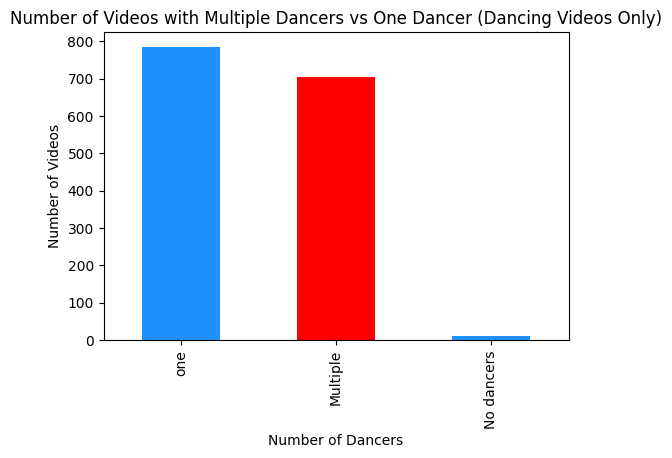

In [43]:
#plot counts of categories
all_dancing = all_videos[all_videos['dancing_encoded'] == 1]

people_count = all_dancing['multiple_people'].value_counts()

plt.figure(figsize=(6, 4))
people_count.plot(kind='bar', color=['dodgerblue', 'red'])

plt.title('Number of Videos with Multiple Dancers vs One Dancer (Dancing Videos Only)')
plt.xlabel('Number of Dancers')
plt.ylabel('Number of Videos')

plt.show()

In [44]:
#filter to dancing videos only
all_dancing_filtered = all_dancing[all_dancing['multiple_people'] != 'No dancers']

In [45]:
video_counts = all_dancing_filtered['multiple_people'].value_counts()

In [ ]:
#plot average likes for multiple dancers

from matplotlib.ticker import FuncFormatter
#sns.set_context("poster", font_scale=0.8)

#average likes for each category 
average_likes = all_dancing_filtered.groupby('multiple_people', as_index=False)['likes'].mean()
video_counts = all_dancing_filtered['multiple_people'].value_counts()

#add counts to each bar
average_likes['count'] = average_likes['multiple_people'].map(video_counts)

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=average_likes, x='multiple_people', y='likes', palette=['dodgerblue', 'red'], width=0.4)


for i, count in enumerate(average_likes['count']):
    ax.text(i, average_likes['likes'][i] / 2, f'{count}', ha='center', va='center', fontsize=14,
            bbox=dict(facecolor='lavender', edgecolor='black', boxstyle='round,pad=0.2', linewidth=2))

one_dancer_index = average_likes[average_likes['multiple_people'] == 'one'].index[0]
one_dancer_bar = ax.patches[one_dancer_index]
ax.text(one_dancer_bar.get_x() + one_dancer_bar.get_width() / 2, one_dancer_bar.get_height() + 0.05,
        "n.s.", ha='center', va='bottom', fontsize=10, color="black", fontweight='bold')

plt.title('Average Likes for Multiple Dancers vs One Dancer', fontweight = 'bold')
plt.xlabel('Number of Dancers', fontweight = 'bold')
plt.ylabel('Average Likes', fontweight = 'bold')

#format y axis
def format_likes(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(FuncFormatter(format_likes))

#plt.savefig('multiple_dancers_3.png', format = 'png', dpi=300, bbox_inches='tight')


plt.show()


In [47]:
video_counts = all_dancing_filtered['multiple_people'].value_counts()
print(video_counts)


multiple_people
one         785
Multiple    704
Name: count, dtype: int64


In [48]:
average_likes

,multiple_people,likes,count
0,Multiple,433858.944602,704
1,one,441908.429299,785


In [49]:
from scipy.stats import f_oneway

multiple_dancers = all_dancing[all_dancing['multiple_people'] == 'Multiple']['likes']
one_dancer = all_dancing[all_dancing['multiple_people'] == 'one']['likes']
f_statistic, p_value = f_oneway(one_dancer, multiple_dancers)

# Print the results
print(f'F-statistic: {f_statistic}')
print(f'P-value: {p_value}')



F-statistic: 0.022912631429519586
P-value: 0.8797050249262738


/tmp/ipykernel_4000961/1556272372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=median_likes, x='multiple_people', y='likes', palette=['dodgerblue', 'red'], width=0.4)


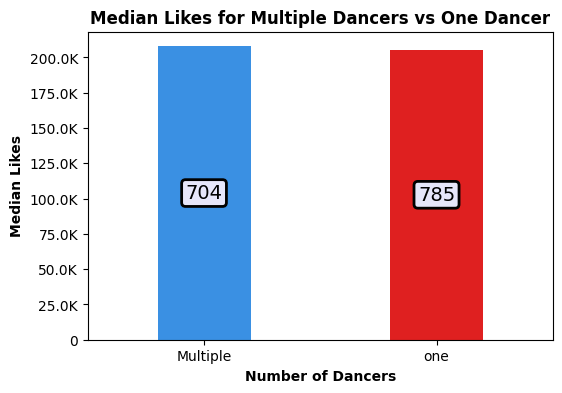

In [55]:
#plot median likes for multiple dancers

from matplotlib.ticker import FuncFormatter
#sns.set_context("poster", font_scale=0.8)
median_likes = all_dancing_filtered.groupby('multiple_people', as_index=False)['likes'].median()
video_counts = all_dancing_filtered['multiple_people'].value_counts()

median_likes['count'] = median_likes['multiple_people'].map(video_counts)

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=median_likes, x='multiple_people', y='likes', palette=['dodgerblue', 'red'], width=0.4)




for i, count in enumerate(median_likes['count']):
    ax.text(i, median_likes['likes'][i] / 2, f'{count}', ha='center', va='center', fontsize=14,
            bbox=dict(facecolor='lavender', edgecolor='black', boxstyle='round,pad=0.2', linewidth=2))

one_dancer_index = median_likes[median_likes['multiple_people'] == 'one'].index[0]
one_dancer_bar = ax.patches[one_dancer_index]

plt.title('Median Likes for Multiple Dancers vs One Dancer', fontweight = 'bold')
plt.xlabel('Number of Dancers', fontweight = 'bold')
plt.ylabel('Median Likes', fontweight = 'bold')



def format_likes(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(FuncFormatter(format_likes))

plt.savefig('multiple_dancers_median.png', format = 'png', dpi=300, bbox_inches='tight')


plt.show()


In [53]:
median_likes

,multiple_people,likes,count
0,Multiple,207850.0,704
1,one,205400.0,785
